# 02 - Exploratory Data Analysis

**Owners: Pornraksa Suksawaeng**

This notebook answers 12 business questions using varied visualizations. Each chart is followed by a written analysis.

**Questions covered:**

| N | Question | Chart type | Owner |
|---|---|---|---|
| 1 | Which products are the bestsellers? | Horizontal bar | Pornraksa |
| 2 | When do customers order? (day + hour) | Heatmap | Pornraksa |
| 3 | Can we predict if a product will be reordered? | → see 03_models | Léo + Mathis |
| 4 | What are the main customer profiles? | → see 04_bonus | Nicolas |
| 5 | Which products are frequently bought together? | → see 04_bonus | Nicolas |
| 6 | Which department has the highest reorder rate? | Bar chart | Pornraksa |
| 7 | Link between days since last order and reorder rate? | Scatter plot | Pornraksa |
| 8 | What proportion of products is organic per department? | Stacked bar | Pornraksa |
| 9 | Which item do customers add to cart first? | Frequency table | Pornraksa |
| 10 | Can we predict the next cart size? | → see 03_models | Léo + Mathis |
| 11 | What is the reorder rate by hour of day? | Line chart | Pornraksa |
| 12 | Which features influence reorder prediction most? | → see 04_bonus SHAP | Nicolas |

## 0. Imports and Setup

In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))
print(f'Dataset loaded with shape: {df.shape}')
df.head()

Dataset loaded with shape: (13690540, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0


### Base dataframes

We define two dataframes here and reuse them throughout the notebook.


In [59]:
df_all = df.copy()

# Exclude first orders, used for any reorder rate analysis
df_reorders = df[df['is_first_order'] == 0].copy()

print(f'df_all shape: {df_all.shape}')
print(f'df_reorders shape: {df_reorders.shape}')
print(f'First orders excluded: {df_all.shape[0] - df_reorders.shape[0]} rows removed')


df_all shape: (13690540, 15)
df_reorders shape: (12811680, 15)
First orders excluded: 878860 rows removed


## Q1 - Which products are the bestsellers?

**Chart: Horizontal bar chart**

We count total order occurrences per product across the entire dataset, and a horizontal bar chart is chose because product names are long and easier to read on the y-axis.

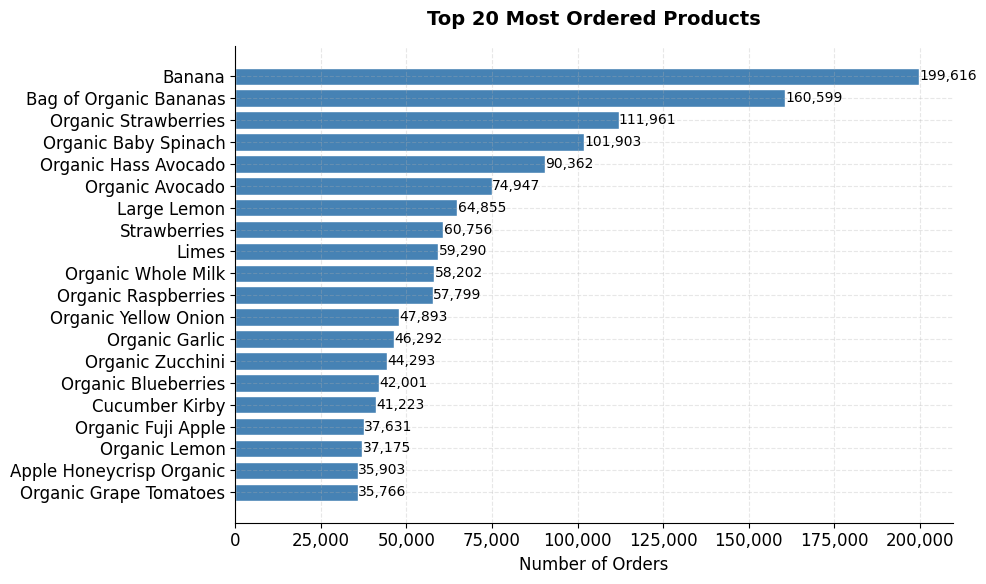

In [60]:
top_n = 20

top_products = (df_all
    .groupby('product_name')['order_id']
    .count()
    .nlargest(top_n)
    .reset_index()
    .rename(columns={'order_id': 'count'})
    .sort_values('count')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_products['product_name'], top_products['count'], color='steelblue', edgecolor='white')

ax.set_xlabel('Number of Orders')
ax.set_title(f'Top {top_n} Most Ordered Products', pad=15)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width()):,}', va='center', fontsize=10)   

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q1_bestsellers.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:**
- Need to note the #1 best selling product and how far ahead ?
- Need to note the pattern in the top product (fresh, organic or staples) ?
- Need to note the business action that a sales manager could take from this insight

## Q2 — When do customers order? (day + hour)

**Chart: Heatmap**

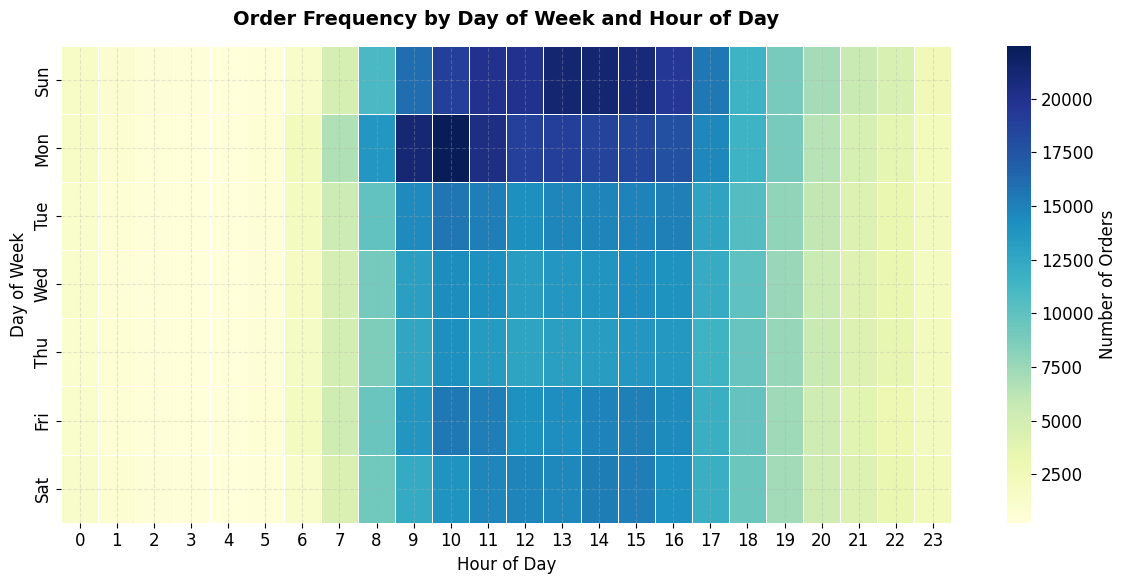

In [61]:
# Deduplicate to order level
order_dedup = df_all.drop_duplicates(subset='order_id')

pivot = order_dedup.pivot_table(
    index='order_dow',
    columns='order_hour_of_day',
    values='order_id',
    aggfunc='count'
)

# order_dow: 0=Sunday, 1=Monday, ..., 6=Saturday
day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot,
    cmap='YlGnBu',
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    yticklabels=day_labels,
    cbar_kws={'label': 'Number of Orders'}
)
ax.set_title('Order Frequency by Day of Week and Hour of Day', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q2_order_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()


**Analysis:**
- Need to note which day and time slot has the most orders 
- Need to note if there are dead zones for example nights, early or mornings
- Need to note what could a retailer do with this information ?

## Q6 - Which department has the highest reorder rate?

**Chart: Horizontal bar chart**

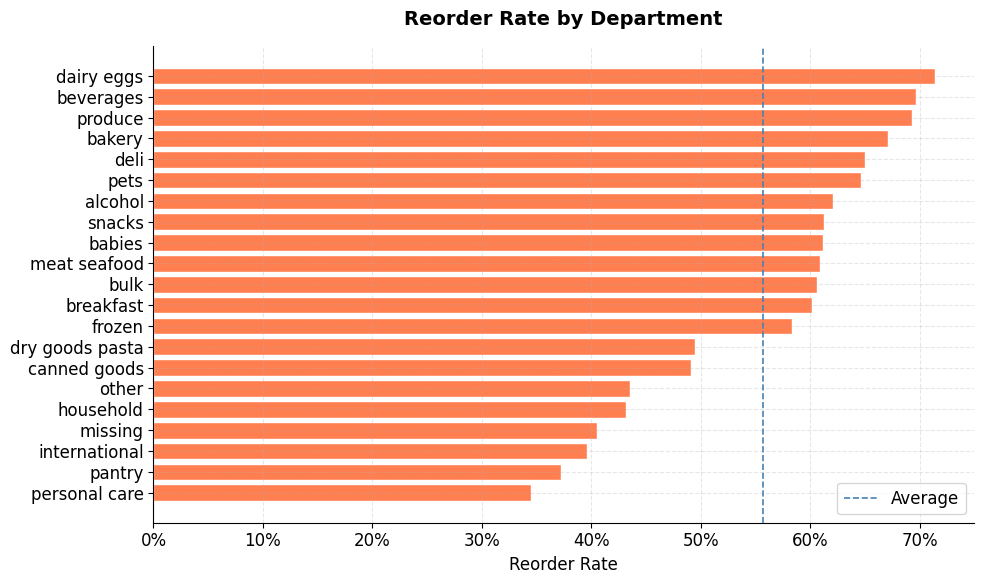

Top 5 Departments by Reorder Rate:
    department  reorder_rate
16        deli      0.650353
17      bakery      0.671187
18     produce      0.692611
19   beverages      0.696632
20  dairy eggs      0.713961


In [62]:
reorder_by_department = (df_reorders
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    reorder_by_department['department'],
    reorder_by_department['reorder_rate'],
    color='coral',
    edgecolor='white'
)

ax.set_xlabel('Reorder Rate')
ax.set_title('Reorder Rate by Department', pad=15)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axvline(
    reorder_by_department['reorder_rate'].mean(),
    color='steelblue',
    linestyle='--',
    linewidth=1.2,
    label='Average'
)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q6_reorder_by_department.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Top 5 Departments by Reorder Rate:')
print(reorder_by_department.tail(5))

**Analysis:**
- Need to note which department has the highest reorder rate and maybe a why
- Need to note which department has the lowest and maybe a why
- Need to note how does this compare to the average dashed line

## Q7 - Link between days since last order and reorder rate?

**Chart: Scatter plot**

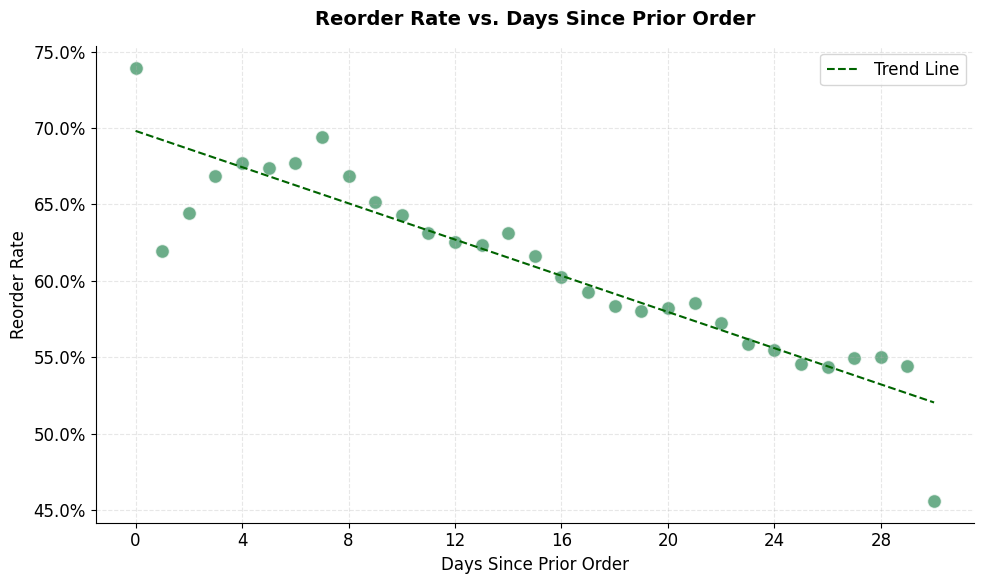

In [63]:
scatter_data = (df_reorders
    .groupby('days_since_prior_order')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    scatter_data['days_since_prior_order'],
    scatter_data['reorder_rate'],
    color='seagreen',
    edgecolor='white',
    s=100,
    alpha=0.7
)

# Trend line
z = np.polyfit(scatter_data['days_since_prior_order'], scatter_data['reorder_rate'], 1)
p = np.poly1d(z)
x_trend = np.linspace(
    scatter_data['days_since_prior_order'].min(),
    scatter_data['days_since_prior_order'].max(),
    100
)
ax.plot(
    x_trend,
    p(x_trend),
    color='darkgreen',
    linestyle='--',
    linewidth=1.5,
    label='Trend Line'
)

ax.set_xlabel('Days Since Prior Order')
ax.set_ylabel('Reorder Rate')
ax.set_title('Reorder Rate vs. Days Since Prior Order', pad=15)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q7_reorder_vs_days_since_prior.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:**
- Need to note if the reorder rate increase or decrease as more day pass
- Need to note what this suggest about the customer loyalty or habit

## Q8 - What proportion of products is organic per department?

**Chart: Stacked horizontal bar chart**


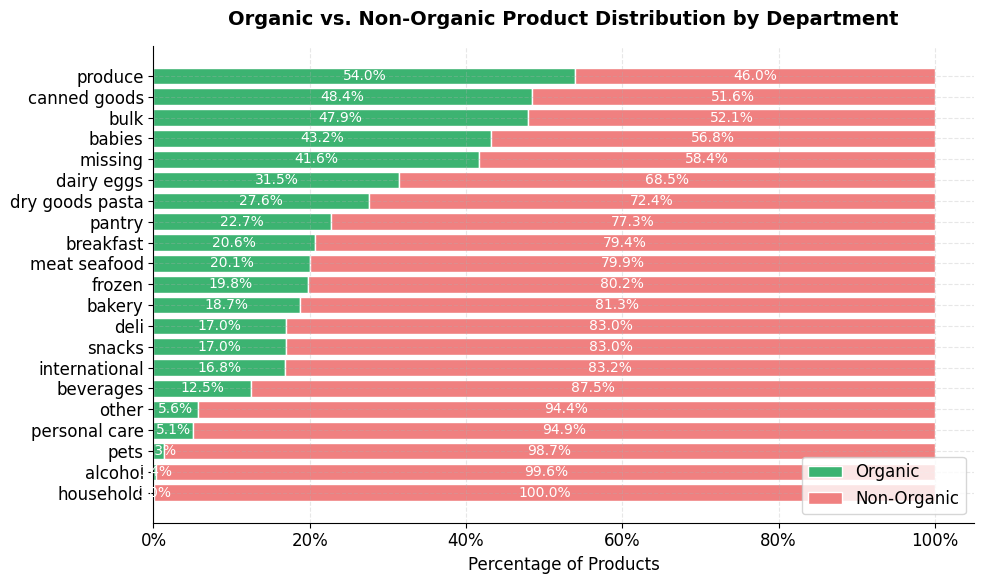

In [64]:
df_all['is_organic'] = df_all['product_name'].str.contains('organic', case=False, na=False).astype(int)

organic = (df_all
    .groupby('department')['is_organic']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'organic_count', 'count': 'total_count'})
)
organic['organic_percentage'] = organic['organic_count'] / organic['total_count']
organic['non_organic_percentage'] = 1 - organic['organic_percentage']
organic = organic.sort_values('organic_percentage')

fix, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    organic.index,
    organic['organic_percentage'],
    color='mediumseagreen',
    edgecolor='white',
    label='Organic'
)
ax.barh(
    organic.index,
    organic['non_organic_percentage'],
    left=organic['organic_percentage'],
    color='lightcoral',
    edgecolor='white',
    label='Non-Organic'
)

# Percentage organic and non organic labels
for i, (organic_pct, non_organic_pct) in enumerate(zip(organic['organic_percentage'], organic['non_organic_percentage'])):
    ax.text(organic_pct / 2, i, f'{organic_pct:.1%}', va='center', ha='center', color='white', fontsize=10)
    ax.text(organic_pct + non_organic_pct / 2, i, f'{non_organic_pct:.1%}', va='center', ha='center', color='white', fontsize=10)

ax.set_xlabel('Percentage of Products')
ax.set_title('Organic vs. Non-Organic Product Distribution by Department', pad=15)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q8_organic_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()


**Analysis:**
- Need to note which department has the highest organic share
- Need to note if there are department with near-zero organic products
- Need to note where to push the organic product lines

## Q9 - Which item do customers add to their cart first ?

**Chart: frequency table and horizontal bar chart**

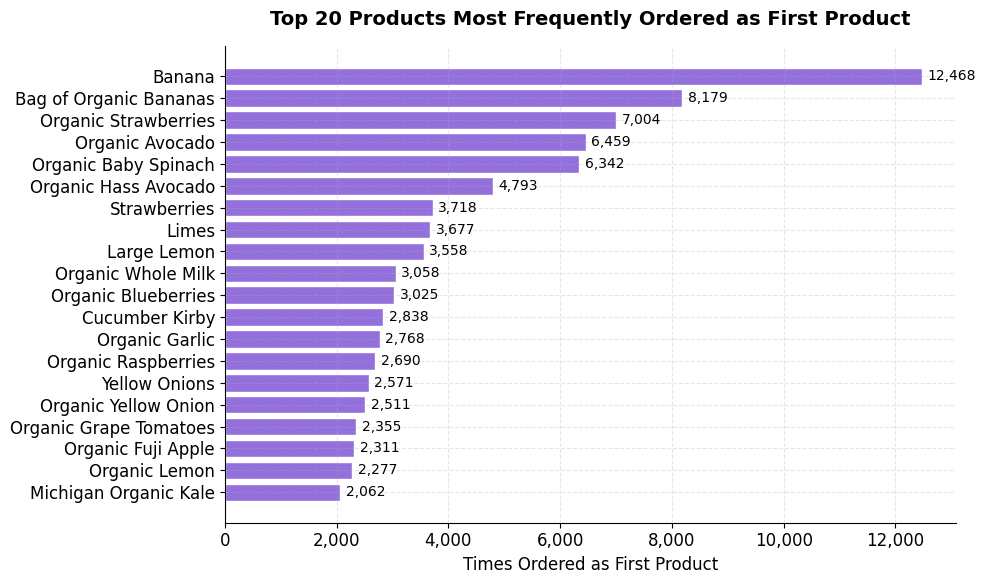

Top 5 Products Most Frequently Ordered as First Product:
             product_name  times_first_product
4    Organic Baby Spinach                 6342
3         Organic Avocado                 6459
2    Organic Strawberries                 7004
1  Bag of Organic Bananas                 8179
0                  Banana                12468


In [65]:
first_items = (df_all[df_all['is_first_order'] == 1]
    .groupby('product_name')['order_id']
    .count()
    .nlargest(top_n)
    .reset_index()
    .rename(columns={'order_id': 'times_first_product'})
    .sort_values('times_first_product')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    first_items['product_name'],
    first_items['times_first_product'],
    color='mediumpurple',
    edgecolor='white'
)

ax.set_xlabel('Times Ordered as First Product')
ax.set_title(f'Top {top_n} Products Most Frequently Ordered as First Product', pad=15)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width()):,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q9_first_product_bestsellers.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Top 5 Products Most Frequently Ordered as First Product:')
print(first_items.tail(5))

**Analysis:**
- Need to note what is the most common first product item
- Need to note if overlap with bestsellers from list q1
- Need to note suggestion about product placement physical or online

## Q11 - What is the reorder rate by the hour of day?

**Chart: Line chart**

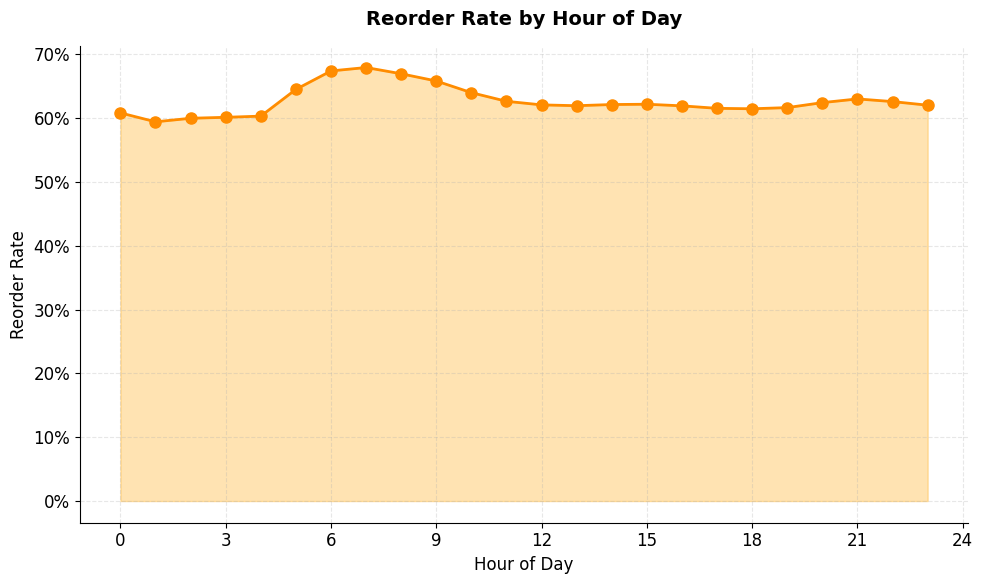

Peak reorder hour: 7:00 with reorder rate of 67.96%
Lowest reorder hour: 1:00 with reorder rate of 59.45%


In [66]:
reorder_by_hour = (df_reorders
    .groupby('order_hour_of_day')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    reorder_by_hour['order_hour_of_day'],
    reorder_by_hour['reorder_rate'],
    marker='o',
    color='darkorange',
    linewidth=2,
    markersize=8
)
ax.fill_between(
    reorder_by_hour['order_hour_of_day'],
    reorder_by_hour['reorder_rate'],
    color='orange',
    alpha=0.3
)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Reorder Rate')
ax.set_title('Reorder Rate by Hour of Day', pad=15)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q11_reorder_by_hour.png'), dpi=300, bbox_inches='tight')
plt.show()

peak_reorder_hour = reorder_by_hour.loc[reorder_by_hour['reorder_rate'].idxmax(), 'order_hour_of_day']
print(f'Peak reorder hour: {peak_reorder_hour}:00 with reorder rate of {reorder_by_hour["reorder_rate"].max():.2%}')

low_reorder_hour = reorder_by_hour.loc[reorder_by_hour['reorder_rate'].idxmin(), 'order_hour_of_day']
print(f'Lowest reorder hour: {low_reorder_hour}:00 with reorder rate of {reorder_by_hour["reorder_rate"].min():.2%}')

**Analysis:**
- Need to note what hour is the reorder rate highest?
- Need to note what hour is the lowest?
- Need to note how to increase sales? online promotions by push notifications?